# Importing basic libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading dataset

In [2]:
from sklearn.datasets import fetch_openml

In [3]:
dataset = fetch_openml(data_id=40499)

In [4]:
dataset.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [23]:
X = dataset.data
y = dataset.target

In [24]:
df = pd.DataFrame(X,columns=dataset.feature_names)
df['class'] = y

In [25]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V32,V33,V34,V35,V36,V37,V38,V39,V40,class
0,-1.223,-0.798,-0.867,-0.639,-0.545,-0.412,-0.795,-0.629,-0.547,-0.868,...,-0.766,-0.555,-0.714,-0.545,-0.587,-0.871,-0.620,-0.568,-0.607,5
1,-1.410,-1.029,-1.013,-0.895,-0.762,-0.676,-1.043,-0.851,-0.775,-1.037,...,-0.919,-0.770,-0.847,-0.663,-0.723,-1.013,-0.748,-0.698,-0.817,5
2,-1.107,-0.649,-0.629,-0.492,-0.367,-0.298,-0.682,-0.478,-0.395,-0.681,...,-0.692,-0.445,-0.588,-0.371,-0.368,-0.746,-0.457,-0.379,-0.469,5
3,-1.270,-0.855,-0.958,-0.707,-0.619,-0.469,-0.872,-0.705,-0.620,-0.988,...,-0.829,-0.719,-0.774,-0.617,-0.688,-0.937,-0.693,-0.657,-0.779,5
4,-1.331,-0.862,-0.761,-0.689,-0.498,-0.361,-0.857,-0.600,-0.496,-0.779,...,-0.861,-0.571,-0.784,-0.545,-0.562,-0.952,-0.642,-0.578,-0.648,5


In [26]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40
count,5500.000000,5500.000000,5500.000000,5500.000000,5500.00000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,...,5500.000000,5500.00000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000,5500.000000
mean,-1.098305,-0.586687,-0.583850,-0.404649,-0.33066,-0.242159,-0.602652,-0.432157,-0.331710,-0.597805,...,-1.098305,-0.64627,-0.491891,-0.643538,-0.491798,-0.593414,-0.779550,-0.554091,-0.523016,-0.567652
std,0.203403,0.205537,0.313495,0.230204,0.23596,0.222505,0.200269,0.221036,0.236053,0.326766,...,0.203403,0.18904,0.330407,0.144121,0.192161,0.170377,0.164106,0.211149,0.201482,0.309110
min,-1.450000,-1.200000,-1.310000,-1.110000,-1.05300,-1.003000,-1.208000,-1.080000,-1.057000,-1.258000,...,-1.450000,-1.17900,-1.147000,-1.123000,-1.015000,-1.030000,-1.253000,-1.097000,-1.076000,-1.215000
25%,-1.218000,-0.712250,-0.771250,-0.535000,-0.48025,-0.345000,-0.720000,-0.584000,-0.484000,-0.828000,...,-1.218000,-0.78100,-0.751250,-0.743000,-0.638000,-0.719000,-0.908000,-0.717000,-0.668000,-0.789000
50%,-1.149000,-0.562000,-0.530000,-0.372000,-0.27200,-0.184000,-0.580000,-0.380000,-0.272000,-0.560000,...,-1.149000,-0.64300,-0.530000,-0.630000,-0.491000,-0.577000,-0.765000,-0.561500,-0.506000,-0.591000
75%,-1.044000,-0.456000,-0.352000,-0.258000,-0.16400,-0.083000,-0.481000,-0.280000,-0.163000,-0.343000,...,-1.044000,-0.54200,-0.253000,-0.559000,-0.338000,-0.464000,-0.686000,-0.397000,-0.367750,-0.345000
max,0.774000,0.330000,0.344000,0.588000,0.43900,0.452000,0.525000,0.398000,0.437000,0.355000,...,0.774000,0.56500,0.675000,0.313000,0.340000,0.156000,0.090000,0.194000,0.202000,0.465000


# Class distribution

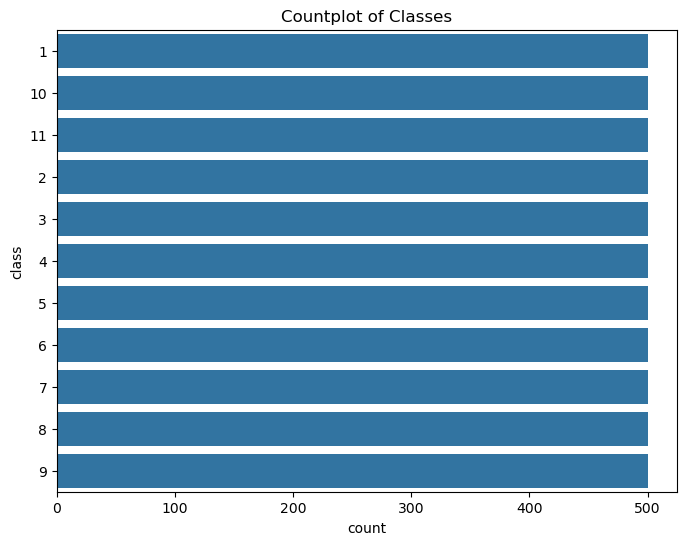

In [27]:
plt.figure(figsize=(8,6))
sns.countplot(df['class'])
plt.title("Countplot of Classes")
plt.show()

In [28]:
print(df['class'].value_counts())

class
1     500
10    500
11    500
2     500
3     500
4     500
5     500
6     500
7     500
8     500
9     500
Name: count, dtype: int64


From the above data, we find that the classes are well balanced

Splitting into training and test dataset

In [29]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [30]:
print(type(X_train))

<class 'pandas.core.frame.DataFrame'>


In [31]:
X_train = X_train.to_numpy()
X_test = X_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

In [32]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4400, 40)
(1100, 40)
(4400,)
(1100,)


# Feature Scaling

Feature scaling is not necessary to be done for the Naive Bayes Classification.

# Implementing Gaussian Naive Bayes from Scratch

In [33]:
class GaussianNBScratch:
  def __init__(self,epsilon=1e-7):
    self.classes = [] # for storing all unique class labels
    self.priors = [] # prior probabilities for each class
    self.mu = [] # mean of features of each class
    self.var = [] # variance of features of each class
    self.epsilon = epsilon # constant for numerical stability

  def _gaussian_likelihoods(self, idx, X):
    mean = self.mu[idx]
    variance = self.var[idx]
    num = np.exp(-((X-mean)**2)/(2*variance))
    den = np.sqrt(2*np.pi*variance)
    return num/den # computing likelihood under gaussian distribution

  def fit(self,X,y):
    self.classes = np.unique(y)
    n_classes = len(self.classes)
    n_features = X.shape[1]

    self.priors = np.zeros(n_classes)
    self.mu = np.zeros((n_classes,n_features))
    self.var = np.zeros((n_classes, n_features))

    for idx, label in enumerate(self.classes):
      X_label = X[y == label] # finding all rows belonging to that class
      self.priors[idx] = X_label.shape[0] / X.shape[0] # compute prior

      self.mu[idx] = np.mean(X_label, axis=0) # compute mean
      self.var[idx] = np.var(X_label, axis=0) + self.epsilon # compute variance

  def predict(self, X):
      y_pred = []
      for x in X:
        posteriors = []
        for idx, label in enumerate(self.classes):
          log_prior = np.log(self.priors[idx])
          log_likelihood = np.sum(np.log(self._gaussian_likelihoods(idx, x)))
          posterior = log_prior + log_likelihood
          posteriors.append(posterior)
        y_pred.append(self.classes[np.argmax(posteriors)]) # select class with maximum posterior
      return np.array(y_pred)

In the above implementation, we have used log probabilities to simplify multiplication of small values into addition.

In [34]:
gnb = GaussianNBScratch()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

In [35]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [36]:
print("Accuracy (Scratch Implementation):",accuracy_score(y_test, y_pred))
print("Precision (Scratch Implementation):",precision_score(y_test, y_pred, average='macro'))
print("Recall (Scratch Implementation):",recall_score(y_test, y_pred, average='macro'))

Accuracy (Scratch Implementation): 0.7818181818181819
Precision (Scratch Implementation): 0.78632977834707
Recall (Scratch Implementation): 0.7847140040761462


In [37]:
print("Confusion Matrix\n",confusion_matrix(y_test, y_pred))

Confusion Matrix
 [[ 57   6   1   0   0   6   0   0   0  38   0]
 [ 15  42   1   0   0  25   0   0   0   6   0]
 [  2  11  54   0   0   3  20   8   2   0   0]
 [  0   0   0  90   0   0   3   0   0   0   0]
 [  1   0   0   0 105   0   0   0   0   0   0]
 [  2   7   1   0   1  79   0  10   0   2   0]
 [  0   1  19   0   0   5  83   2  10   0   0]
 [  0   0   1   0   0  13   8  72   0   0   0]
 [  0   0   1   0   0   0   6   0 101   0   0]
 [  0   0   2   0   0   0   0   0   0  87   0]
 [  0   0   1   0   0   0   0   0   0   0  90]]


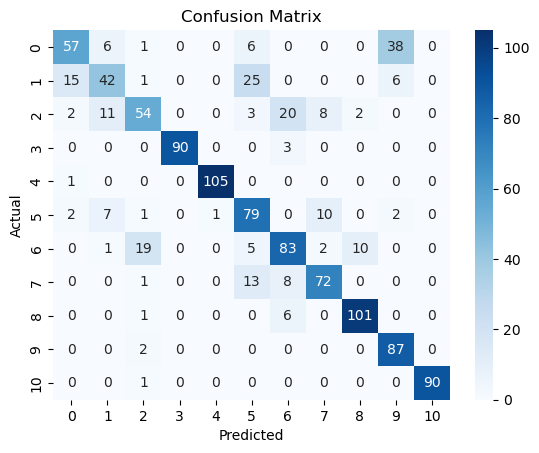

In [39]:
sns.heatmap(confusion_matrix(y_test, y_pred),annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix")
plt.show()

#Scikit learn implementation of Gaussian Naive Bayes

In [40]:
from sklearn.naive_bayes import GaussianNB
gnb_sklearn = GaussianNB()
gnb_sklearn.fit(X_train, y_train)
y_pred_sklearn = gnb_sklearn.predict(X_test)

In [41]:
print("Accuracy (Sklearn implementation):",accuracy_score(y_test, y_pred_sklearn))
print("Precision (Sklearn implementation):",precision_score(y_test, y_pred_sklearn, average='macro'))
print("Recall (Sklearn implementation):",recall_score(y_test, y_pred_sklearn, average='macro'))

Accuracy (Sklearn implementation): 0.7818181818181819
Precision (Sklearn implementation): 0.78632977834707
Recall (Sklearn implementation): 0.7847140040761462


Both implementations perform similarly in terms of accuracy, precision and recall but the scikit learn implementation is faster and more optimized.
